# 01 Data Understanding

This notebook loads and validates the Orange Belgium churn-uplift dataset used in Beyond Churn.

## Goals

- verify dataset structure
- identify treatment and outcome variables
- inspect feature types
- inspect missing values
- measure treatment/control balance
- measure churn rates by treatment group
- understand the experimental structure

Note that no predictive or causal models are fit in this notebook.

In [46]:
import numpy as np
import pandas as pd
import sklearn
import openml
import matplotlib.pyplot as plt
import seaborn as sns
from pandas.plotting import scatter_matrix
import statsmodels

print("NumPy:", np.__version__)
print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("statsmaodels:", statsmodels.__version__)
print("OpenML:", openml.__version__)

NumPy: 2.5.1
pandas: 3.0.5
scikit-learn: 1.9.0
statsmaodels: 0.14.6
OpenML: 0.15.1


## Load the Orange Belgium dataset

The dataset is retrieved from OpenML rather than stored directly in this repository.

- OpenML dataset ID: `45580`
- Dataset name: `churn-uplift-orange`

In [2]:
dataset = openml.datasets.get_dataset(45580)

print("Name:", dataset.name)
print("Version:", dataset.version)
print("OpenML ID:", dataset.dataset_id)
print("Default target:", dataset.default_target_attribute)

Name: churn-uplift-mlg
Version: 1
OpenML ID: 45580
Default target: y


In [3]:
X, y, categorical_indicator, attribute_names = dataset.get_data(
    dataset_format="dataframe",
    target=dataset.default_target_attribute
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (11896, 179)
y shape: (11896,)


In [4]:
# check out the X and y datasets
display(X.head())
display(y.head())

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,FACTOR10,FACTOR11,FACTOR12,FACTOR13,FACTOR14,FACTOR15,FACTOR16,FACTOR17,FACTOR18,t
0,-3.064007,-1.272259,-4.075844,1.492514,2.328039,-0.330240,-0.770389,0.035541,2.439325,-0.847266,...,V3,V2,V2,V5,V20,V9,V11,V1,V4,0
1,-4.574066,-3.541815,1.107371,0.447314,-0.471140,-0.567309,0.195963,0.383654,1.523472,-0.184596,...,V4,V2,V3,V6,V20,V9,V15,V4,V4,0
2,-1.751471,-2.039692,-3.788823,0.624226,0.564614,-0.713385,1.003502,1.582819,-1.461687,0.844975,...,V4,V5,V2,V11,V20,V9,V1,V4,V4,1
3,-2.030089,-0.235720,-5.711960,1.071841,2.441541,0.758484,-0.534295,1.614289,-1.022909,-1.383025,...,V3,V2,V2,V4,V20,V11,V1,V4,V4,1
4,-2.377857,-2.478670,-1.051946,2.812768,2.019267,0.095542,-0.033324,-1.332319,4.316526,-0.537967,...,V3,V2,V2,V7,V20,V2,V1,V2,V2,1


0    0
1    0
2    0
3    0
4    0
Name: y, dtype: uint8

In [5]:
# column names
print("Columns:")
for col in X.columns:
    print(col)

Columns:
PC1
PC2
PC3
PC4
PC5
PC6
PC7
PC8
PC9
PC10
PC11
PC12
PC13
PC14
PC15
PC16
PC17
PC18
PC19
PC20
PC21
PC22
PC23
PC24
PC25
PC26
PC27
PC28
PC29
PC30
PC31
PC32
PC33
PC34
PC35
PC36
PC37
PC38
PC39
PC40
PC41
PC42
PC43
PC44
PC45
PC46
PC47
PC48
PC49
PC50
PC51
PC52
PC53
PC54
PC55
PC56
PC57
PC58
PC59
PC60
PC61
PC62
PC63
PC64
PC65
PC66
PC67
PC68
PC69
PC70
PC71
PC72
PC73
PC74
PC75
PC76
PC77
PC78
PC79
PC80
PC81
PC82
PC83
PC84
PC85
PC86
PC87
PC88
PC89
PC90
PC91
PC92
PC93
PC94
PC95
PC96
PC97
PC98
PC99
PC100
PC101
PC102
PC103
PC104
PC105
PC106
PC107
PC108
PC109
PC110
PC111
PC112
PC113
PC114
PC115
PC116
PC117
PC118
PC119
PC120
PC121
PC122
PC123
PC124
PC125
PC126
PC127
PC128
PC129
PC130
PC131
PC132
PC133
PC134
PC135
PC136
PC137
PC138
PC139
PC140
PC141
PC142
PC143
PC144
PC145
PC146
PC147
PC148
PC149
PC150
PC151
PC152
PC153
PC154
PC155
PC156
PC157
PC158
PC159
PC160
FACTOR1
FACTOR2
FACTOR3
FACTOR4
FACTOR5
FACTOR6
FACTOR7
FACTOR8
FACTOR9
FACTOR10
FACTOR11
FACTOR12
FACTOR13
FACTOR14
FACTOR15
FACTOR16
FACT

## Treatment and outcome audit

Before we do any modeling let's verify the coding and empirical distributions of the treatment and outcome variables

- `t` represents treatment assignment
- `y` is the churn outcome

We need to make sure `t` is binary, whether it's encoded `0/1` (or strings), which values mean treatment, which value means control, whether `y=1` is churn or retention, number of observations, and how rare is churn.

inspect their observed values

In [6]:
# Treatment distribution
treatment_counts = X["t"].value_counts(dropna=False).sort_index()
treatment_rates = X["t"].value_counts(
    normalize=True,
    dropna=False
).sort_index()

# summary
treatment_summary = pd.DataFrame({
    "count": treatment_counts,
    "proportion": treatment_rates
})

treatment_summary

,count,proportion
t,,
0,2886,0.242603
1,9010,0.757397


In [7]:
# outcome distribution
outcome_counts = y.value_counts(dropna=False).sort_index()
outcome_rates = y.value_counts(
    normalize=True,
    dropna=False
).sort_index()

outcome_summary = pd.DataFrame({
    "count": outcome_counts,
    "proportion": outcome_rates
})

outcome_summary

,count,proportion
y,,
0,11488,0.965703
1,408,0.034297


In [8]:
print("Treatment values:", X["t"].unique())
print("Outcome values:", y.unique())

Treatment values: [0 1]
Outcome values: [0 1]


In [9]:
# crosstab
pd.crosstab(
    X["t"],
    y,
    margins=True
)

y,0,1,All
t,,,
0,2781,105,2886
1,8707,303,9010
All,11488,408,11896


### observations

The dataset contains 11,896 customers, with approximately 75.7% assigned to treatment and 24.3% assigned to control.

Churn is relatively rare: only 408 customers (3.43%) have `y = 1`.

The raw churn rate is slightly lower in the treatment group than in the control group:

- Control: approximately 3.64%
- Treatment: approximately 3.36%

This suggests a small average association between treatment and reduced churn. However, the primary goal of this project is not only to estimate the average effect of treatment, but to investigate whether treatment effects vary across customers.

The low number of churn events will also be an important consideration when designing train/test splits, uplift evaluation, and subgroup analyses.

### Dataframe Copy
- To organize things and help with EDA I'll create a single dataframe that keeps X and y together.

In [11]:
df = X.copy()
df["y"] = y

print(f'shape = {df.shape}')

df[["t", "y"]].head()

shape = (11896, 180)


,t,y
0,0,0
1,0,0
2,1,0
3,1,0
4,1,0


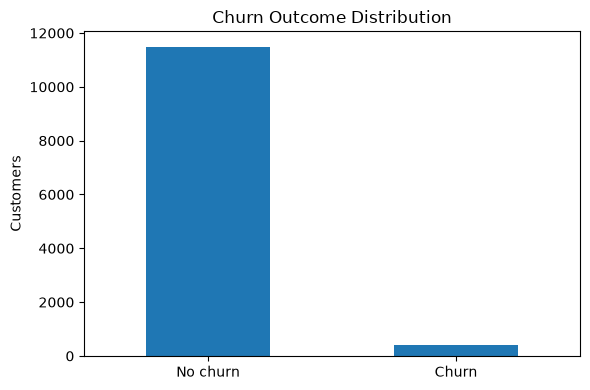

In [12]:
# churn plot
# we can visualize this as a rare event problem
outcome_plot = (
    df["y"]
    .value_counts()
    .sort_index()
    .rename(index={0: "No churn", 1: "Churn"})
)

fig, ax = plt.subplots(figsize=(6, 4))

outcome_plot.plot(
    kind="bar",
    ax=ax
)

ax.set_ylabel("Customers")
ax.set_xlabel("")
ax.set_title("Churn Outcome Distribution")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

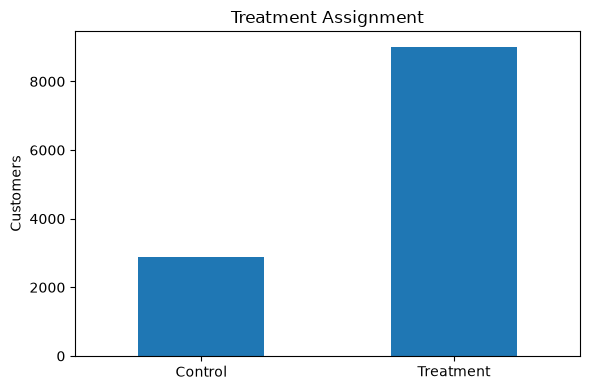

In [13]:
# treatment allocation plot
# this shows the ~24/76 split
treatment_plot = (
    df["t"]
    .value_counts()
    .sort_index()
    .rename(index={0: "Control", 1: "Treatment"})
)

fig, ax = plt.subplots(figsize=(6, 4))

treatment_plot.plot(
    kind="bar",
    ax=ax
)

ax.set_ylabel("Customers")
ax.set_xlabel("")
ax.set_title("Treatment Assignment")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Dataset integrity

Next we check the dataset for any common structural issues like:

- duplicate observations
- missing values
- feature data types
- constant features
- feature family composition

These checks help determine what preprocessing might be required later and whether any features should be excluded before modeling

In [14]:
# shape and duplicates
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

duplicate_rows = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_rows:,}")
print(f"Duplicate rate: {duplicate_rows / len(df):.2%}")

Rows: 11,896
Columns: 180
Duplicate rows: 0
Duplicate rate: 0.00%


In [15]:
# missing values
missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .to_frame("missing_count")
)

missing["missing_pct"] = missing["missing_count"] / len(df)

missing.head(20)

,missing_count,missing_pct
PC1,0,0.0
PC2,0,0.0
PC3,0,0.0
PC4,0,0.0
PC5,0,0.0
PC6,0,0.0
PC7,0,0.0
PC8,0,0.0
PC9,0,0.0
PC10,0,0.0


In [16]:
print("Columns with missing values:", (missing["missing_count"] > 0).sum())
print("Total missing cells:", df.isna().sum().sum())

Columns with missing values: 0
Total missing cells: 0


In [17]:
# datatypes
df.dtypes.value_counts()

float64    160
str         18
uint8        2
Name: count, dtype: int64

In [18]:
numeric_cols = df.select_dtypes(
    include=["number"]
).columns.tolist()

categorical_cols = df.select_dtypes(
    include=["str", "category"]
).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))
print("Categorical columns:", categorical_cols)

Numeric columns: 162
Categorical columns: 18
Categorical columns: ['FACTOR1', 'FACTOR2', 'FACTOR3', 'FACTOR4', 'FACTOR5', 'FACTOR6', 'FACTOR7', 'FACTOR8', 'FACTOR9', 'FACTOR10', 'FACTOR11', 'FACTOR12', 'FACTOR13', 'FACTOR14', 'FACTOR15', 'FACTOR16', 'FACTOR17', 'FACTOR18']


In [19]:
# create predictor feature groups for future modeling
pc_cols = [col for col in df.columns if col.startswith("PC")]
factor_cols = [col for col in df.columns if col.startswith("FACTOR")]

feature_cols = pc_cols + factor_cols

print("Principal-component features:", len(pc_cols))
print("Factor features:", len(factor_cols))
print("Total predictor features:", len(feature_cols))

Principal-component features: 160
Factor features: 18
Total predictor features: 178


### Missingness and feature types

The dataset contains no missing values.

The predictor set consists of:

- 160 continuous principal-component features (`PC1`–`PC160`)
- 18 categorical factor features (`FACTOR1`–`FACTOR18`)
- one binary treatment indicator (`t`)
- one binary churn outcome (`y`)

The absence of missing values simplifies preprocessing. The main preprocessing decisions will instead involve handling the anonymized categorical factor variables and determining whether scaling is required for specific estimators.

### Constant and low cardinality features

- check whether any predictors are constant or nearly constant
- inspect the cardinality of the anonymized categorical features

Note that constant features carry will not carry any meaningful predictive information and should be removed

In [20]:
# Constant and low cardinality features

unique_counts = df[feature_cols].nunique(dropna=False)

constant_features = unique_counts[unique_counts <= 1]

print("Constant features:", len(constant_features))
display(constant_features)

display(unique_counts.sort_values().head(25))

Constant features: 1


FACTOR3    1
dtype: int64

FACTOR3         1
FACTOR8         2
FACTOR7         3
FACTOR12        3
FACTOR11        3
FACTOR9         4
FACTOR5         4
FACTOR10        4
FACTOR17        6
FACTOR18        7
FACTOR13       12
FACTOR2        12
FACTOR16       17
FACTOR1        18
FACTOR6        20
FACTOR4        20
FACTOR15       20
FACTOR14       20
PC1         11896
PC2         11896
PC5         11896
PC6         11896
PC3         11896
PC4         11896
PC9         11896
dtype: int64

In [21]:
# for categorical variables specifically
factor_cardinality = (
    df[factor_cols]
    .nunique(dropna=False)
    .sort_values()
    .to_frame("n_unique")
)

factor_cardinality

,n_unique
FACTOR3,1
FACTOR8,2
FACTOR7,3
FACTOR12,3
FACTOR11,3
FACTOR10,4
FACTOR9,4
FACTOR5,4
FACTOR17,6
FACTOR18,7


In [22]:
# Inspect category levels for factor variables

for col in factor_cols:
    print(f"\n{col}: {df[col].nunique()} levels")
    print(df[col].value_counts(dropna=False).head(10))


FACTOR1: 18 levels
FACTOR1
V10    5516
V3     1393
V14    1374
V16    1130
V18     564
V15     474
V2      456
V12     332
V6      315
V4      163
Name: count, dtype: int64

FACTOR2: 12 levels
FACTOR2
V10    8065
V9     1663
V13    1607
V16     282
V15     118
V8       52
V2       27
V3       27
V11      23
V14      16
Name: count, dtype: int64

FACTOR3: 1 levels
FACTOR3
V2    11896
Name: count, dtype: int64

FACTOR4: 20 levels
FACTOR4
V12    3319
V10    2615
V7     1278
V8      978
V9      895
V11     868
V3      572
V16     468
V5      326
V1      175
Name: count, dtype: int64

FACTOR5: 4 levels
FACTOR5
V1    6497
V2    3862
V3    1363
V4     174
Name: count, dtype: int64

FACTOR6: 20 levels
FACTOR6
V19    3234
V20    2505
V13    1004
V10     911
V5      729
V15     726
V3      338
V2      269
V4      257
V9      243
Name: count, dtype: int64

FACTOR7: 3 levels
FACTOR7
V3    8672
V2    2759
V4     465
Name: count, dtype: int64

FACTOR8: 2 levels
FACTOR8
V1    11892
V2        4
Name:

### Integrity audit summary

The dataset contains one constant predictor:

- `FACTOR3` which has the same value for all 11,896 observations

Because constant features contain no predictive information `FACTOR3` should be excluded from modeling.

The categorical factor variables vary in cardinality - e.g., some are binary variables and some have factors with ~20 levels. Several factors also contain very rare categories - e.g., `FACTOR8` has one level represented by only four observations.

Sparse categories might need to be handled carefully when doing one-hot encoded linear models or when we are interpreting small subgroups. Note that I will not do any category collapsing at this current stage. I'll focus on preprocessing decisions during the modeling pipeline to avoid modifying this raw exploratory data.

In [23]:
# make a clean feature list with removed constants
constant_features = unique_counts[unique_counts <= 1].index.tolist()

model_feature_cols = [
    col for col in feature_cols
    if col not in constant_features
]

print("Original predictors:", len(feature_cols))
print("Constant predictors removed:", constant_features)
print("Modeling predictors:", len(model_feature_cols))

Original predictors: 178
Constant predictors removed: ['FACTOR3']
Modeling predictors: 177


## Treatment-control covariate balance

Because this dataset comes from an experiment the treatment and control users should be comparable on pretreatment characteristics

We can evaluate balance using `standardized mean differences` (SMDs) rather than hypothesis-test p-values. When we get very large samples then even small and practically insignificant differences can become statistically significant.

For example, when running experiments we might want to check trustworthiness and proper balance using a plurality of methods. SRM can help check whether the observed allocation counts match the intended split. Covariate balance can check whether treatment and control look similar on pre-treatment variables. SMDs can quantify the size of the imbalance. A chi-square can test whether imbalance is statistically detectable (but these tests are sample-size sensitive). Note that if we were to run many tests due to having many covariates, then we should use corrected p-values to help control for false positives.

For a numeric feature, the standardized mean difference is:

$$
\text{SMD}
=
\frac{\bar{x}_{T} - \bar{x}_{C}}
{\sqrt{\frac{s_T^2 + s_C^2}{2}}}
$$

NOTE: a common diagnostic convention is that an absolute SMD value below 0.10 indicates relatively small imbalance. Some conventions I've seen:

- if < 0.05: very small imbalance
- if 0.05 - 0.10: modest
- if > 0.10: worth more attention
- if > 0.20: high / notable

I use a `love plot` below to visualize this. A love plot is essentially a *covariate balance plot*. The x-axis is the `absolute standardized mean difference`. So a dot near 0 means treatment and control are nearly identical on that variable. But a dot farther right means more imbalance. I create dashed vertical lines at 0.05 and 0.10 because these are *heuristic* reference thresholds. Also note that I'm using *absolute SMD* in the plot, as the direction is not really the main concern here (by direction I'm refering to the sigh: positive or negative - or control is higher vs test is higher) 

In [24]:
balance_rows = []

for col in pc_cols:
    treated = df.loc[df["t"] == 1, col]
    control = df.loc[df["t"] == 0, col]

    mean_t = treated.mean()
    mean_c = control.mean()

    var_t = treated.var(ddof=1)
    var_c = control.var(ddof=1)

    pooled_sd = np.sqrt((var_t + var_c) / 2)

    smd = (
        (mean_t - mean_c) / pooled_sd
        if pooled_sd > 0
        else np.nan
    )

    balance_rows.append({
        "feature": col,
        "mean_treated": mean_t,
        "mean_control": mean_c,
        "smd": smd,
        "abs_smd": abs(smd)
    })

numeric_balance = (
    pd.DataFrame(balance_rows)
      .sort_values("abs_smd", ascending=False)
      .reset_index(drop=True)
)

numeric_balance.head(20)

,feature,mean_treated,mean_control,smd,abs_smd
0,PC8,-0.098442,0.307332,-0.219743,0.219743
1,PC28,0.047862,-0.149423,0.167762,0.167762
2,PC1,0.124990,-0.390214,0.128389,0.128389
3,PC2,0.088476,-0.276218,0.110840,0.110840
4,PC7,0.055337,-0.172760,0.110770,0.110770
5,PC12,0.039590,-0.123599,0.106420,0.106420
6,PC4,-0.063265,0.197510,-0.104576,0.104576
7,PC132,-0.004101,0.012803,-0.099027,0.099027
8,PC20,-0.034024,0.106222,-0.097996,0.097996
9,PC19,0.028985,-0.090491,0.087349,0.087349


In [25]:
print(
    "Max absolute SMD:",
    round(numeric_balance["abs_smd"].max(), 4)
)

print(
    "Median absolute SMD:",
    round(numeric_balance["abs_smd"].median(), 4)
)

print(
    "Features with |SMD| > 0.10:",
    (numeric_balance["abs_smd"] > 0.10).sum()
)

print(
    "Features with |SMD| > 0.05:",
    (numeric_balance["abs_smd"] > 0.05).sum()
)

Max absolute SMD: 0.2197
Median absolute SMD: 0.0228
Features with |SMD| > 0.10: 7
Features with |SMD| > 0.05: 30


In [26]:
numeric_balance.loc[
    numeric_balance["abs_smd"] > 0.10,
    ["feature", "mean_treated", "mean_control", "smd", "abs_smd"]
]

,feature,mean_treated,mean_control,smd,abs_smd
0,PC8,-0.098442,0.307332,-0.219743,0.219743
1,PC28,0.047862,-0.149423,0.167762,0.167762
2,PC1,0.124990,-0.390214,0.128389,0.128389
3,PC2,0.088476,-0.276218,0.110840,0.110840
4,PC7,0.055337,-0.172760,0.110770,0.110770
5,PC12,0.039590,-0.123599,0.106420,0.106420
6,PC4,-0.063265,0.197510,-0.104576,0.104576


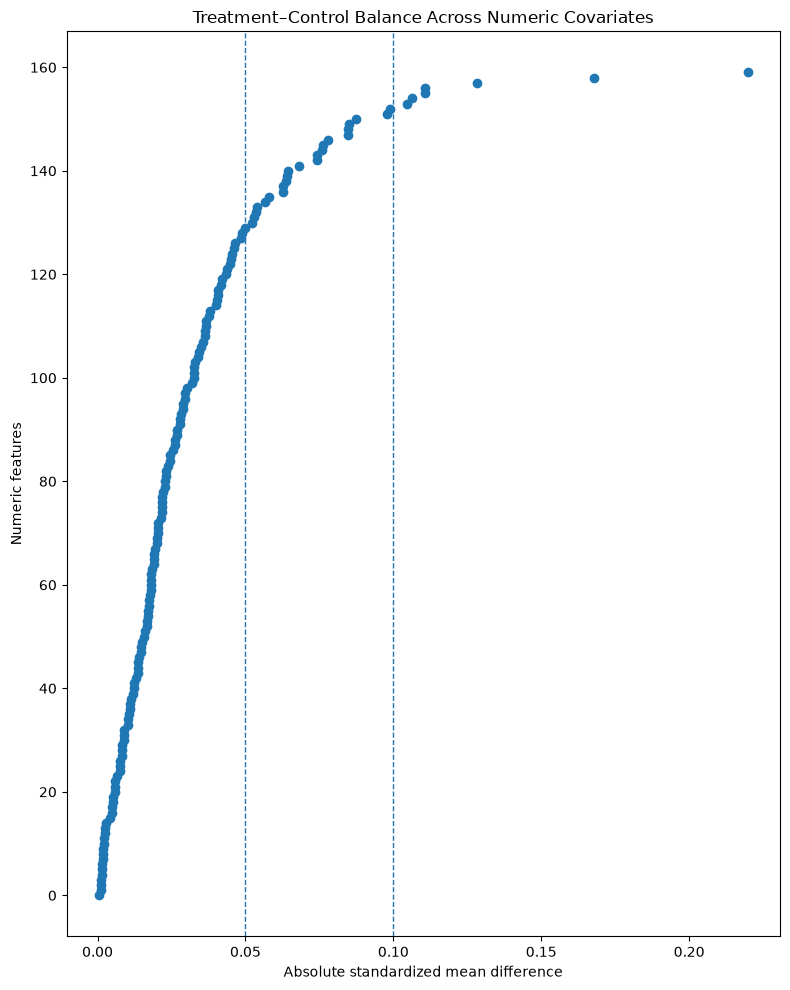

In [27]:
# love plot


balance_plot = numeric_balance.sort_values("abs_smd", ascending=True)

fig, ax = plt.subplots(figsize=(8, 10))

ax.scatter(
    balance_plot["abs_smd"],
    range(len(balance_plot))
)

ax.axvline(0.05, linestyle="--", linewidth=1)
ax.axvline(0.10, linestyle="--", linewidth=1)

ax.set_xlabel("Absolute standardized mean difference")
ax.set_ylabel("Numeric features")
ax.set_title("Treatment–Control Balance Across Numeric Covariates")

plt.tight_layout()
plt.show()

### Numeric Balance Summary
Most numeric covariates exhibit small treatment-control differences with a median absolute SMD of 0.023. But 7 out of 160 principal component features exceed an absolute SMD of **0.10**. The largest imbalance is approximately 0.22. This motivates a closer examination of the experiment assignment structure and could favor some kind of covariate-adjusted causal estimation in later analyses

### Categorical covariate balance

For the categorical predictors balance can be assessed at the *category level*.

So each category is treated as a binary indicator, and the standardized mean difference for a binary variable is:

$$
\text{SMD}
=
\frac{p_T - p_C}
{\sqrt{
\frac{
p_T(1-p_T)+p_C(1-p_C)
}{2}
}}
$$

where $p_T$ and $p_C$ are the proportions of treated and control customers in that category.

Note that this is the same goal as teh numeric SMD check because we will measure how different treatment and control are on a pre-treatment covariate using a standardized scale. The difference here is that numeric and categorical variables need different formulas.
- for numeric variables we compare the means between groups
- for categorical variables we first turn it into a binary indicator and then compre the proportions and standardize the difference using the variance of a binary variable.

*Summary*:
Numeric SMD: standardized difference in group means.
Categorical SMD: treat each category level as a binary indicator and compute the standardized difference in group proportions.
But both answer the same question: “How different are treatment and control on this pre-treatment characteristic?”

`FACTOR3` is excluded because it is constant across all observations.

Also note that we already saw that some categories are *rare* - e.g., `FACTOR8=V2` only has ~ 4 users.  Binary SMDs can behave awkwardlys or be hard to interpret for sparse categories. So we can also kepp the counts with the balance stats

In [28]:
# Categorical treatment-control balance

categorical_balance_rows = []

balance_factor_cols = [
    col for col in factor_cols
    if col not in constant_features
]

for col in balance_factor_cols:
    levels = df[col].dropna().unique()

    for level in levels:
        treated_indicator = (
            df.loc[df["t"] == 1, col] == level
        ).astype(int)

        control_indicator = (
            df.loc[df["t"] == 0, col] == level
        ).astype(int)

        p_t = treated_indicator.mean()
        p_c = control_indicator.mean()

        pooled_sd = np.sqrt(
            (
                p_t * (1 - p_t)
                + p_c * (1 - p_c)
            ) / 2
        )

        smd = (
            (p_t - p_c) / pooled_sd
            if pooled_sd > 0
            else np.nan
        )

        categorical_balance_rows.append({
            "feature": col,
            "level": level,
            "proportion_treated": p_t,
            "proportion_control": p_c,
            "smd": smd,
            "abs_smd": abs(smd)
        })

categorical_balance = (
    pd.DataFrame(categorical_balance_rows)
      .sort_values("abs_smd", ascending=False)
      .reset_index(drop=True)
)

categorical_balance.head(20)

,feature,level,proportion_treated,proportion_control,smd,abs_smd
0,FACTOR18,V7,0.495671,0.319473,0.364482,0.364482
1,FACTOR4,V10,0.249279,0.127859,0.314213,0.314213
2,FACTOR6,V10,0.087791,0.041580,0.188708,0.188708
3,FACTOR18,V2,0.175805,0.248094,-0.177577,0.177577
4,FACTOR4,V7,0.094562,0.147609,-0.163150,0.163150
5,FACTOR18,V4,0.267370,0.334719,-0.147221,0.147221
6,FACTOR4,V12,0.262930,0.329175,-0.145494,0.145494
7,FACTOR2,V10,0.693119,0.630631,0.132379,0.132379
8,FACTOR4,V16,0.032852,0.059598,-0.127636,0.127636
9,FACTOR4,V11,0.080577,0.049203,0.127624,0.127624


In [29]:
# summary
print(
    "Max absolute categorical SMD:",
    round(categorical_balance["abs_smd"].max(), 4)
)

print(
    "Median absolute categorical SMD:",
    round(categorical_balance["abs_smd"].median(), 4)
)

print(
    "Levels with |SMD| > 0.10:",
    (categorical_balance["abs_smd"] > 0.10).sum()
)

print(
    "Levels with |SMD| > 0.05:",
    (categorical_balance["abs_smd"] > 0.05).sum()
)

Max absolute categorical SMD: 0.3645
Median absolute categorical SMD: 0.0258
Levels with |SMD| > 0.10: 13
Levels with |SMD| > 0.05: 32


In [30]:
# check out the materially imbalanced levels
categorical_balance.loc[
    categorical_balance["abs_smd"] > 0.10,
    [
        "feature",
        "level",
        "proportion_treated",
        "proportion_control",
        "smd",
        "abs_smd"
    ]
]

,feature,level,proportion_treated,proportion_control,smd,abs_smd
0,FACTOR18,V7,0.495671,0.319473,0.364482,0.364482
1,FACTOR4,V10,0.249279,0.127859,0.314213,0.314213
2,FACTOR6,V10,0.087791,0.041580,0.188708,0.188708
3,FACTOR18,V2,0.175805,0.248094,-0.177577,0.177577
4,FACTOR4,V7,0.094562,0.147609,-0.163150,0.163150
5,FACTOR18,V4,0.267370,0.334719,-0.147221,0.147221
6,FACTOR4,V12,0.262930,0.329175,-0.145494,0.145494
7,FACTOR2,V10,0.693119,0.630631,0.132379,0.132379
8,FACTOR4,V16,0.032852,0.059598,-0.127636,0.127636
9,FACTOR4,V11,0.080577,0.049203,0.127624,0.127624


In [31]:
# add counts next to categories because binary SMDs can be bizarre looking with very sparse categories
categorical_balance["count_total"] = categorical_balance.apply(
    lambda row: (
        df[row["feature"]] == row["level"]
    ).sum(),
    axis=1
)

categorical_balance.head(20)

,feature,level,proportion_treated,proportion_control,smd,abs_smd,count_total
0,FACTOR18,V7,0.495671,0.319473,0.364482,0.364482,5388
1,FACTOR4,V10,0.249279,0.127859,0.314213,0.314213,2615
2,FACTOR6,V10,0.087791,0.041580,0.188708,0.188708,911
3,FACTOR18,V2,0.175805,0.248094,-0.177577,0.177577,2300
4,FACTOR4,V7,0.094562,0.147609,-0.163150,0.163150,1278
5,FACTOR18,V4,0.267370,0.334719,-0.147221,0.147221,3375
6,FACTOR4,V12,0.262930,0.329175,-0.145494,0.145494,3319
7,FACTOR2,V10,0.693119,0.630631,0.132379,0.132379,8065
8,FACTOR4,V16,0.032852,0.059598,-0.127636,0.127636,468
9,FACTOR4,V11,0.080577,0.049203,0.127624,0.127624,868


### Categorical balance findings

Categorical balance is assessed by treating each category level as a binary indicator and comparing its prevalence between treatment and control.

This is analogous to the numeric SMD check:

- numeric SMD compares standardized differences in means
- categorical SMD compares standardized differences in proportions

Most categorical levels show relatively small treatment-control differences with a median absolute SMD of 0.026.

However, 13 category levels exceed an absolute SMD of 0.10. Several of the largest imbalances involve common categories rather than rare levels. For example, `FACTOR18 = V7` occurs in approximately 49.6% of treated customers versus 31.9% of control customers, corresponding to an absolute SMD of approximately 0.36.

Together with the numeric balance results, this suggests that treatment and control are not globally balanced across all observed pretreatment covariates. This motivates closer examination of the original assignment mechanism and supports the use of covariate-adjusted causal estimation in later stages of the project.

In [32]:
# combined numeric and categorical love plot

numeric_love = numeric_balance[
    ["feature", "abs_smd"]
].copy()

numeric_love["covariate"] = numeric_love["feature"]
numeric_love["type"] = "Numeric PC"

categorical_love = categorical_balance[
    ["feature", "level", "abs_smd"]
].copy()

categorical_love["covariate"] = (
    categorical_love["feature"]
    + " = "
    + categorical_love["level"].astype(str)
)
categorical_love["type"] = "Categorical level"

love_data = pd.concat(
    [
        numeric_love[["covariate", "type", "abs_smd"]],
        categorical_love[["covariate", "type", "abs_smd"]]
    ],
    ignore_index=True
)

love_data = love_data.sort_values(
    "abs_smd",
    ascending=True
).reset_index(drop=True)

love_data.tail(20)

,covariate,type,abs_smd
315,FACTOR12 = V3,Categorical level,0.103563
316,PC4,Numeric PC,0.104576
317,FACTOR6 = V20,Categorical level,0.106151
318,PC12,Numeric PC,0.106420
319,PC7,Numeric PC,0.110770
320,PC2,Numeric PC,0.110840
321,FACTOR18 = V6,Categorical level,0.125450
322,FACTOR4 = V11,Categorical level,0.127624
323,FACTOR4 = V16,Categorical level,0.127636
324,PC1,Numeric PC,0.128389


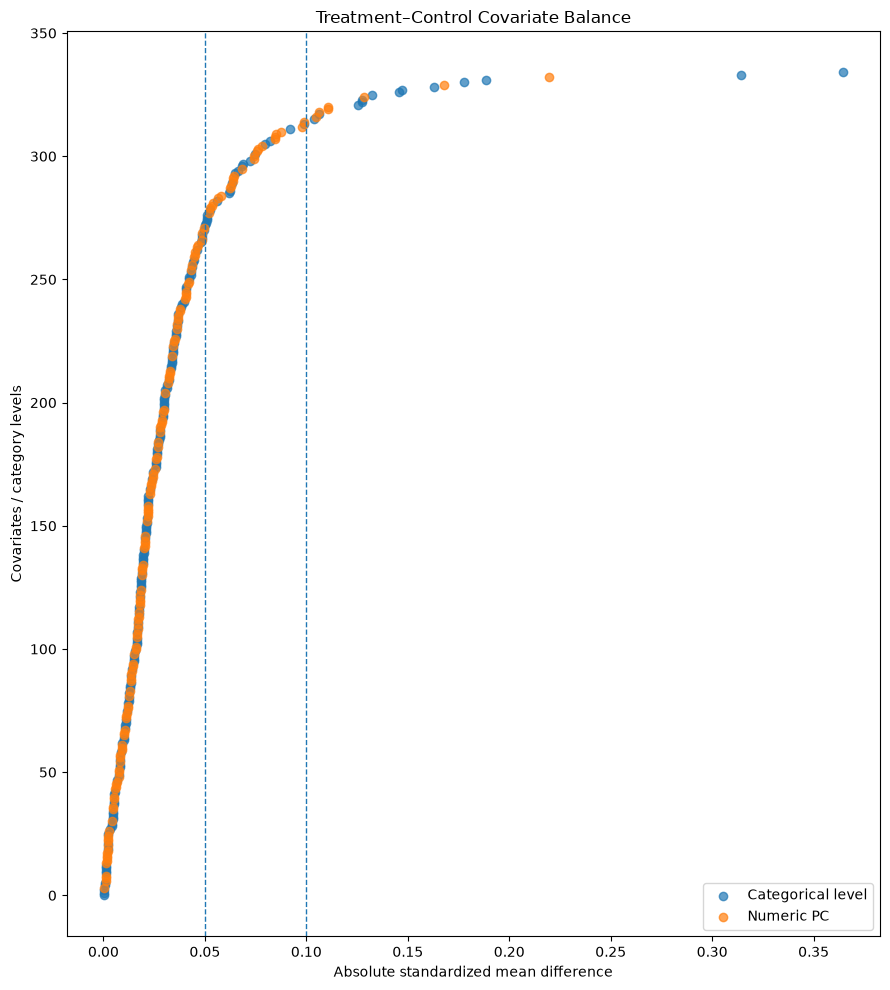

In [33]:
# combined plot
# basically tells us: across all measured pretreatment dimensions, how balanced are treatment and control?
fig, ax = plt.subplots(figsize=(9, 10))

for covariate_type, group in love_data.groupby("type"):
    ax.scatter(
        group["abs_smd"],
        group.index,
        label=covariate_type,
        alpha=0.7
    )

ax.axvline(0.05, linestyle="--", linewidth=1)
ax.axvline(0.10, linestyle="--", linewidth=1)

ax.set_xlabel("Absolute standardized mean difference")
ax.set_ylabel("Covariates / category levels")
ax.set_title("Treatment–Control Covariate Balance")
ax.legend()

plt.tight_layout()
plt.show()

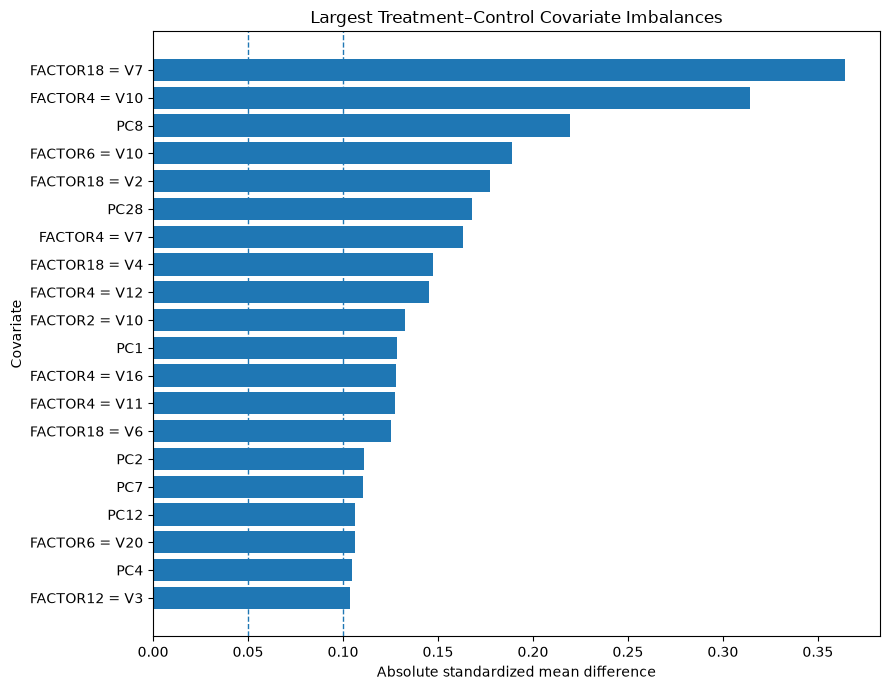

In [34]:
# top imbalance plot
top_imbalances = (
    love_data
    .sort_values("abs_smd", ascending=False)
    .head(20)
    .sort_values("abs_smd")
)

fig, ax = plt.subplots(figsize=(9, 7))

ax.barh(
    top_imbalances["covariate"],
    top_imbalances["abs_smd"]
)

ax.axvline(0.05, linestyle="--", linewidth=1)
ax.axvline(0.10, linestyle="--", linewidth=1)

ax.set_xlabel("Absolute standardized mean difference")
ax.set_ylabel("Covariate")
ax.set_title("Largest Treatment–Control Covariate Imbalances")

plt.tight_layout()
plt.show()

## Select EDA Visualizations
- Visualizations here are intentionally limited because the features are anonymized and include variables derived from PCA. My goal is to understand broad structure. SMD love plots above were useful. Additionally, we could explore a basic PC correlation heatmap, scatter matrix (constrained), and some representative categorical distributions

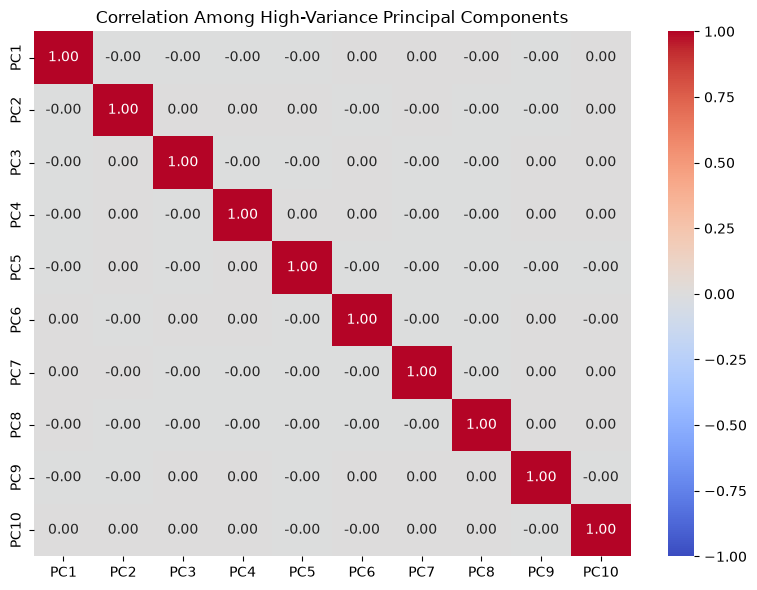

In [36]:
# I'll first get a set of representative principal components
# compute the variances of them and get the 10 principal components with highest variance
# then compute how correlated they are with each other and visualize

# correlation heatmap will summarize linear correlation

pc_variances = df[pc_cols].var().sort_values(ascending=False)
top_var_pcs = pc_variances.head(10).index.tolist()

# Compute correlations
corr_matrix = df[top_var_pcs].corr()

# Plot correlation heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

plt.title("Correlation Among High-Variance Principal Components")
plt.tight_layout()
plt.show()

### Principal component correlation

The selected high variance principal components show no meaningful pairwise linear correlation.

This is consistent with the expected behavior of PCA derived features, which are constructed to be orthogonal. So the heatmap is mainly serving as a kind of structural sanity check rather than revealing some meaningful multicollinearity among the selected PCs.

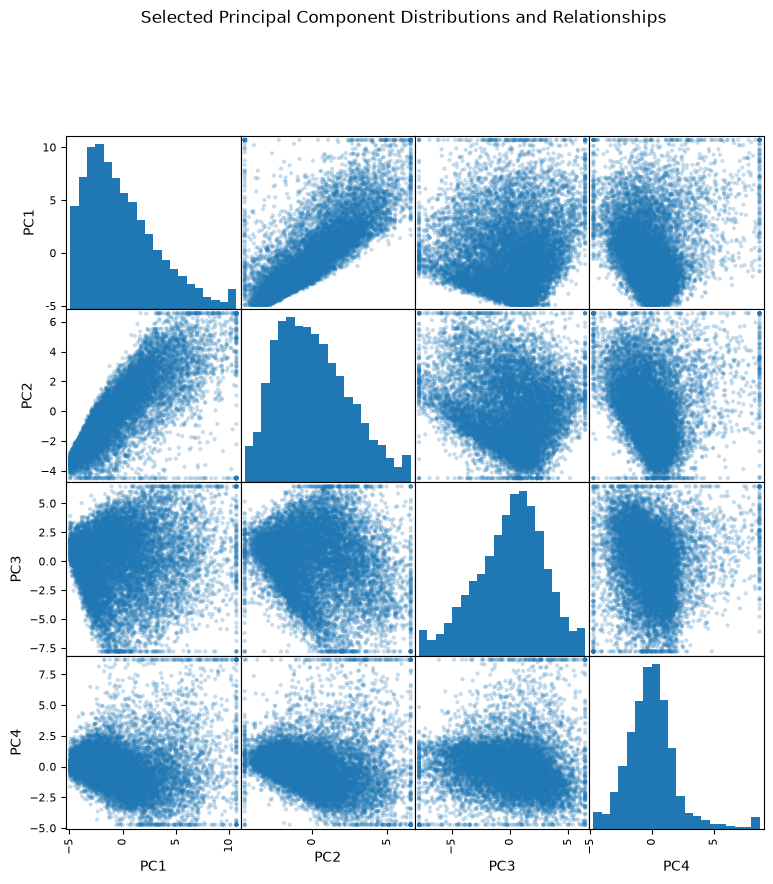

In [41]:
# scatter matrix of select high variance PCA variables
# make a grid of plots where the diagonal cells show a histogram for each PC that help us answer what the distribution of the PC looks like
# the other cells are scatter plots comparing every pair of PCs to help find relationships
# note that I use clipping here to handle some outliers - I'm clipping at 1st and 99th percetile to get a better visualization of the actual distribution shape and avoid outliers dominating the axes

eda_pcs = top_var_pcs[:4]

eda_plot_data = df[eda_pcs].copy()

for col in eda_pcs:
    lower = eda_plot_data[col].quantile(0.01)
    upper = eda_plot_data[col].quantile(0.99)
    eda_plot_data[col] = eda_plot_data[col].clip(lower, upper)

scatter_matrix(
    eda_plot_data,
    figsize=(9, 9),
    diagonal="hist",
    alpha=0.25,
    hist_kwds={"bins": 20}
)

plt.suptitle(
    "Selected Principal Component Distributions and Relationships",
    y=1.02
)

plt.show()

### Selected PC distributions and pairwise structures

After clipping the selected PCs to the 1st and 99th percentiles for visualization only the distributions and pairwise relationships are easier to inspect

Selected components show different distribution shapes, including skewness and heavier tails, while the scatter plots show visible nonlinear structure despite near-zero Pearson correlations

Note that low linear correlation does not mean the absence of relationships between variables. The clipping is used only for visualization. And the underlying modeling data remain unchanged.

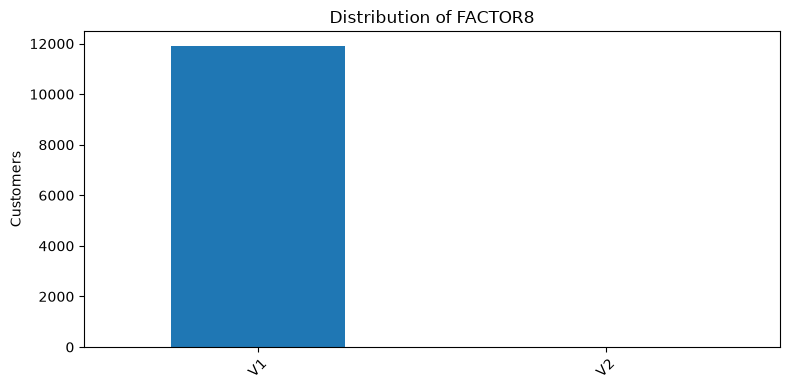

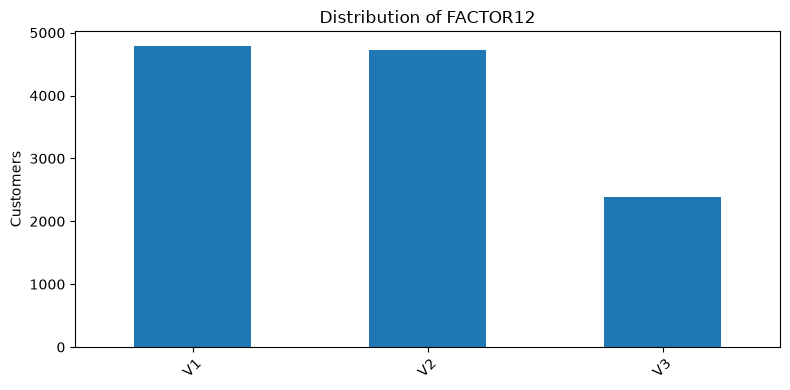

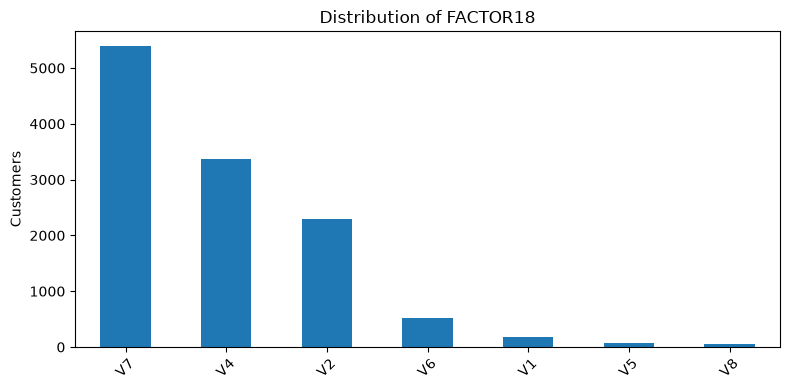

In [42]:
# plot for categorical variables
# FACTOR8 had only two levels but was very imbalanced - V2 had 4 users. plotting can show this and highlight why cardinality alone will not always tell us if categories have sufficient support for reliable modeling

selected_factors = [
    "FACTOR8",
    "FACTOR12",
    "FACTOR18"
]

for col in selected_factors:
    counts = df[col].value_counts().sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(8, 4))

    counts.plot(
        kind="bar",
        ax=ax
    )

    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel("")
    ax.set_ylabel("Customers")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

### Representative categorical distributions

These plots show the frequency distribution of selected categorical predictors with different levels of sparsity and cardinality.

- `FACTOR8` is very sparse: almost all users belong to `V1` while `V2` contains only a small number of observations.
- `FACTOR12` is much more balanced across its three categories.
- `FACTOR18` has a more uneven multi-level distribution, with `V7`, `V4`, and `V2` accounting for most observations and several much smaller categories.

These illustrate why categorical variables with the same nominal type can behave differently in modeling. Rare levels can be unstable for one-hot encoded models or other subgroup analysis, while more balanced factors can provide broader support across categories.

# Experimental average treatment effect
- this is the unadjusted difference in churn rates between randomized treatment and control groups
- Note that I did find some noticeable covariate imbalance. Randomization can still produce some chance imbalance. Covariate adjustment can improve precision but it is not necessary to make the comparison causal since this was a random experiment. But the observed imbalance is useful and later covariate - adjusted estimates might help us test robustness and potentially improve our precision
- In the next cells I'll first define treatment and control outcomes, get basic effect estimates, calculate confidence intervals for the risk difference, run a hypothesis test and get p-value, summarize and visualize

In [48]:
# separate churn outcomes for the arms and get observed churn rates
# we can calculate risk difference: absolute pp change in churn
# and we can calculate relative risk: treatment churn risk relative to control churn risk
control = df.loc[df["t"] == 0, "y"]
treated = df.loc[df["t"] == 1, "y"]

control_rate = control.mean()
treated_rate = treated.mean()

risk_difference = treated_rate - control_rate
relative_risk = treated_rate / control_rate

# display basic effect estimates
print(f"Control churn rate: {control_rate:.4%}")
print(f"Treatment churn rate: {treated_rate:.4%}")
print(f"Risk difference: {risk_difference:.4%}")
print(f"Relative risk: {relative_risk:.4f}")

Control churn rate: 3.6383%
Treatment churn rate: 3.3629%
Risk difference: -0.2753%
Relative risk: 0.9243


In [49]:
# confidence interval for the risk difference using statsmodels
# we can quantify uncertainty around the observed treatment effect
# I'm using newcomb for method for default difference between two proportions
from statsmodels.stats.proportion import confint_proportions_2indep

ci_low, ci_high = confint_proportions_2indep(
    count1=treated.sum(),
    nobs1=len(treated),
    count2=control.sum(),
    nobs2=len(control),
    compare="diff",
    method="newcomb"
)

print(
    f"95% CI for risk difference: "
    f"[{ci_low:.4%}, {ci_high:.4%}]"
)

95% CI for risk difference: [-1.1015%, 0.4617%]


In [50]:
# hypothesis test comparing two independent proportions
# H0: treatment churn rate - control churn rate = 0
# H1: treatemtn churn rate - control churn rate != 0
from statsmodels.stats.proportion import test_proportions_2indep

test_result = test_proportions_2indep(
    count1=treated.sum(),
    nobs1=len(treated),
    count2=control.sum(),
    nobs2=len(control),
    compare="diff",
    alternative="two-sided"
)

print(f"Test statistic: {test_result.statistic:.3f}")
print(f"P-value: {test_result.pvalue:.4f}")

Test statistic: -0.746
P-value: 0.4557


In [51]:
# summary
effect_summary = pd.DataFrame({
    "Metric": [
        "Control churn rate",
        "Treatment churn rate",
        "Risk difference",
        "Relative risk",
        "95% CI lower",
        "95% CI upper",
        "P-value"
    ],
    "Value": [
        control_rate,
        treated_rate,
        risk_difference,
        relative_risk,
        ci_low,
        ci_high,
        test_result.pvalue
    ]
})

effect_summary

,Metric,Value
0,Control churn rate,0.036383
1,Treatment churn rate,0.033629
2,Risk difference,-0.002753
3,Relative risk,0.924325
4,95% CI lower,-0.011015
5,95% CI upper,0.004617
6,P-value,0.455676


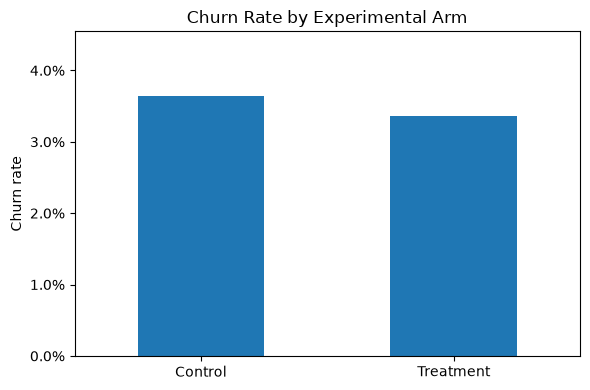

In [52]:
# visualize treatment and control churn rates
churn_rates = pd.Series({
    "Control": control_rate,
    "Treatment": treated_rate
})

fig, ax = plt.subplots(figsize=(6, 4))

churn_rates.plot(
    kind="bar",
    ax=ax
)

ax.set_ylabel("Churn rate")
ax.set_title("Churn Rate by Experimental Arm")
ax.set_ylim(0, churn_rates.max() * 1.25)

ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda y, _: f"{y:.1%}")
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

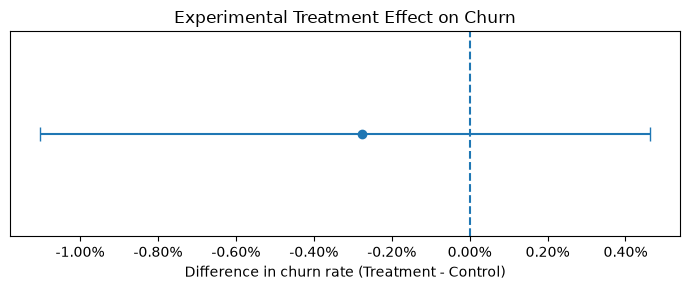

In [53]:
# visualize treatment effect confidence interval plot
fig, ax = plt.subplots(figsize=(7, 3))

ax.errorbar(
    risk_difference,
    0,
    xerr=[
        [risk_difference - ci_low],
        [ci_high - risk_difference]
    ],
    fmt="o",
    capsize=5
)

ax.axvline(0, linestyle="--")

ax.set_yticks([])
ax.set_xlabel("Difference in churn rate (Treatment - Control)")
ax.set_title("Experimental Treatment Effect on Churn")

ax.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f"{x:.2%}")
)

plt.tight_layout()
plt.show()

### Experimental treatment-effect summary

The control-group churn rate was approximately **3.64%** compared with **3.36%** in the treatment group.

The estimated treatment effect on churn was therefore **-0.28 percentage points**. That means the treated group experienced slightly lower churn on average. The relative risk was **0.92**, corresponding to roughly an **8% relative reduction in churn** compared with control.

However, the **95% confidence interval for the risk difference ranged from approximately -1.10 to +0.46 percentage points**, which includes zero. The two-sided hypothesis test also produced a **p-value of 0.456**.

So, taken together, the experiment does not provide strong evidence of a nonzero average treatment effect across the full customer population. The point estimate is directionally favorable, but the uncertainty is large enough to include no effect and a small adverse effect.

This is a solid motivation for the next stages of my project: a weak or statistically uncertain average effect might not rule out meaningful **heterogeneous treatment effects**. The intervention may help some users substantially while having little or no effect on others.

## Key takeaways

- The dataset contains 11,896 customers, 160 principal-component features, 18 categorical factors, a treatment indicator, and a binary churn outcome.
- Churn is relatively rare at approximately 3.4%, which will make class imbalance an important consideration for predictive modeling.
- The dataset contains no missing values, although `FACTOR3` is constant and should be excluded from modeling.
- Several categorical variables contain highly sparse levels, which should be handled carefully during preprocessing.
- Most principal components show little pairwise linear correlation, as expected for PCA-derived features, although the scatter matrix reveals some nonlinear structure.
- Treatment and control are broadly similar across many observed features, but several numeric and categorical covariates show noticeable imbalance.
- The randomized treatment group had a slightly lower churn rate than control: 3.36% versus 3.64%.
- The estimated average treatment effect was approximately **-0.28 percentage points**, but the 95% confidence interval included zero and the two-sided p-value was **0.456**.
- Therefore, there is not strong evidence that the intervention reduced churn on average across the full population.
- A weak average effect does not imply that the treatment is ineffective for everyone. Treatment effects may vary substantially across customers, motivating later heterogeneous treatment-effect and uplift modeling.

## Next step

The next notebook will establish the **predictive churn baseline**.

The goal will be to answer a different question from the experiment analysis:

> **Who is most likely to churn?**

We will begin with some interpretable baseline models and evaluate discrimination, class imbalance, and probability calibration before later comparing churn risk with estimated treatment responsiveness.

This distinction is central to the project:

> **The customer most likely to churn is not necessarily the customer most likely to be saved.**